# D3 — DoorKey-6×6 atoms-only causal control

Actor and critic consume only nine named atoms; the continuous 1280-D feature has no policy bypass. This is a jointly trained policy-facing symbolic head, **not a post-hoc distillation of D1**.

The notebook is the visual acceptance companion. Frozen paper evidence uses 100 same-generator episodes in `results/doorkey_experiment_3_d3/`; the saved animation and smaller live checks here are for inspection. Evaluation RNG seeds are separated, but the generator audit found complete static-layout support overlap.

## ① 配置区 — 模型 / 环境 / 种子（改一行即可切换）

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
import numpy as np
import torch
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DengXian']
matplotlib.rcParams['axes.unicode_minus'] = False
import matplotlib.pyplot as plt

HERE = pathlib.Path.cwd()
REPO = HERE if (HERE / "dreamer.py").exists() else HERE.parent  # notebooks/ 下 cwd 是自己的目录，父目录才是仓库根
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "scripts"))

# ── 顶部配置：改这几行即可切换模型/环境/演示局 ──
MODEL_PATH = REPO / "models" / "doorkey" / "doorkey_experiment_3_d3" / "checkpoint.pt"
TASK       = "doorkey6x6"
ENV_ID     = "MiniGrid-DoorKey-6x6-v0"
DEMO_SEED  = 3          # 走迷宫动画用哪一局；必须落在测试池 0~199（训练从未见过）；与 D1 用同一 seed 便于对比同一张图
USE_NDNF   = True       # True: belief 面板显示阈值化后【激活/未激活】的具名谓词；False: 显示原子连续激活值(tanh, 未阈值化)条形图
N_EVAL     = 20         # 通关率/ablation 用的批量局数
DEVICE     = "cuda:0" if torch.cuda.is_available() else "cpu"

TRAIN_SEED_START, TEST_POOL = 10_000, 200
print(f"训练 seed 池: [{TRAIN_SEED_START}, {TRAIN_SEED_START+100_000}) 随机采样  |  测试 seed 池: [0, {TEST_POOL})")
print(f"DEMO_SEED = {DEMO_SEED}  -> 属于测试池 ({0 <= DEMO_SEED < TEST_POOL})，训练阶段从未见过这张地图")
print(f"MODEL_PATH = {MODEL_PATH}  exists={MODEL_PATH.exists()}")
print(f"DEVICE = {DEVICE}   USE_NDNF = {USE_NDNF}")


训练 seed 池: [10000, 110000) 随机采样  |  测试 seed 池: [0, 200)
DEMO_SEED = 3  -> 属于测试池 (True)，训练阶段从未见过这张地图
MODEL_PATH = c:\Users\super\Desktop\test\Xdreamer\models\doorkey\doorkey_experiment_3_d3\checkpoint.pt  exists=True
DEVICE = cuda:0   USE_NDNF = True


In [2]:
# 加载符号瓶颈世界模型（复用 ablate_sym.load，与训练时一致的 config/obs/act 空间）
import ablate_sym as A
import envs.minigrid as M
import envs.wrappers as wrappers

agent, config = A.load(str(MODEL_PATH), DEVICE, ["defaults", "minigrid", "minigrid_symbolic_nav"])
wm, behavior = agent._wm, agent._task_behavior
LABELS = list(wm._sym_head.labels)
K = wm.sym_dim
policy_input = wm._sym_policy_input
actor_in_dim = behavior.actor.layers[0].in_features
nparams = sum(p.numel() for p in agent.parameters())

print(f"模型类型: DreamerV3 + N-DNF 符号瓶颈 (_sym_head enabled, sym_policy_input='{policy_input}')")
print(f"参数量: {nparams:,}")
print(f"actor 输入维度: {actor_in_dim}  (= {K} 个具名逻辑原子，连续 1280 维 feat 已被切断——真瓶颈)")
print(f"具名原子（{K}）: {LABELS}")
print(f"动作空间: {config.num_actions} (VALID_ACTIONS=[0,1,2,3,5]，去掉 drop/done)")


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Encoder CNN shapes: {}
Encoder MLP shapes: {'grid': (148,)}
Decoder CNN shapes: {}
Decoder MLP shapes: {'grid': (148,)}
Symbolic belief head enabled: feat1280->9 atoms labels=['has_key', 'door_locked', 'door_open', 'carrying', 't_ahead', 't_left', 't_right', 't_reach', 'wall_ahead'] n_lit=48 mask=none loss=mse scale=2.0 (atoms shape WM AND feed policy)
Optimizer model_opt has 12519024 variables.
Optimizer actor_opt has 70149 variables.
Optimizer value_opt has 134399 variables.
模型类型: DreamerV3 + N-DNF 符号瓶颈 (_sym_head enabled, sym_policy_input='atoms')
参数量: 12,857,971
actor 输入维度: 9  (= 9 个具名逻辑原子，连续 1280 维 feat 已被切断——真瓶颈)
具名原子（9）: ['has_key', 'door_locked', 'door_open', 'carrying', 't_ahead', 't_left', 't_right', 't_reach', 'wall_ahead']
动作空间: 5 (VALID_ACTIONS=[0,1,2,3,5]，去掉 drop/done)


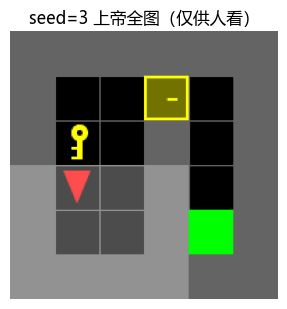

mission: use the key to open the door and then get to the goal
key_pos=(1, 2)  door_pos=(3, 1)  goal_pos=(4, 4)  agent_pos=(1, 3) agent_dir=1
!! 这张全图 + god_state() 只用作人看 / 监督标签，模型的 obs 里只有 148 维局部 grid，从未见过这张图 !!
!! 策略实际吃到的是这 9 个具名原子（从 belief 预测出来的），不是 god_state 真值 !!


In [3]:
# 上帝全图（只给人看，绝不喂给模型）+ mission + 关键物体位置
demo_env = A.make_env(TASK, DEMO_SEED, config.time_limit)
obs0 = demo_env.reset()
god0 = demo_env.god_state()
frame0 = demo_env.render()
mission = demo_env._env.unwrapped.mission

plt.figure(figsize=(3.2, 3.2))
plt.imshow(frame0); plt.axis("off")
plt.title(f"seed={DEMO_SEED} 上帝全图（仅供人看）")
plt.tight_layout(); plt.show()

print(f"mission: {mission}")
print(f"key_pos={god0['key_pos']}  door_pos={god0['door_pos']}  goal_pos={god0['goal_pos']}  "
      f"agent_pos={god0['agent_pos']} agent_dir={god0['agent_dir']}")
print("!! 这张全图 + god_state() 只用作人看 / 监督标签，模型的 obs 里只有 148 维局部 grid，从未见过这张图 !!")
print("!! 策略实际吃到的是这 9 个具名原子（从 belief 预测出来的），不是 god_state 真值 !!")
demo_env.close()


## ② N-DNF rule extraction and per-predicate grounding

The N-DNF head is present during training. `sym_rules()` hardens the learned conjunction/disjunction weights for inspection; this is rule extraction, not a newly trained post-hoc controller.

In [4]:
# 滚 N_EVAL 局纯策略 eval（测试池种子），收集每步 atoms / grid / god 标签 / 是否通关
@torch.no_grad()
def collect_atoms(seed0, episodes, tl):
    rows, successes = [], []
    for ep in range(episodes):
        env = A.make_env(TASK, seed0 + ep, tl)
        obs = env.reset(); latent = action = None
        succ, t = False, 0
        for t in range(tl + 1):
            ob = {k: np.array(v)[None] for k, v in obs.items() if not k.startswith("log_")}
            data = wm.preprocess(ob); embed = wm.encoder(data)
            latent, _ = wm.dynamics.obs_step(latent, action, embed, data["is_first"], sample=False)
            feat = wm.dynamics.get_feat(latent)
            atoms = wm._sym_head.atoms(feat)                 # (1,K) in [-1,1]，真原子
            pol = wm.augment(feat)                            # 策略实际输入（瓶颈=只有 atoms）
            action = behavior.actor(pol).mode()
            a = int(torch.argmax(action, -1)[0].item())
            g = env.god_state()
            rows.append({
                "atoms": atoms[0].cpu().numpy().astype(np.float32),
                "grid":  obs["grid"].astype(np.float32),
                "episode": ep,
                **{lab: int(g[lab]) for lab in LABELS},
            })
            obs, r, done, _ = env.step(a)
            if done: succ = bool(r > 0); break
        env.close()
        successes.append(succ)
    return rows, successes

rows2, succ2 = collect_atoms(0, N_EVAL, config.time_limit)
print(f"滚了 {N_EVAL} 局（测试池 seeds 0..{N_EVAL-1}），通关率 {np.mean(succ2):.1%} ({sum(succ2)}/{N_EVAL})")
ep2 = np.array([r["episode"] for r in rows2])
succ_mask2 = np.array([succ2[e] for e in ep2])
atoms2 = np.array([r["atoms"] for r in rows2])[succ_mask2]
grid2  = np.array([r["grid"]  for r in rows2])[succ_mask2]
ep2f   = ep2[succ_mask2]
labels_y2 = {lab: np.array([r[lab] for r in rows2])[succ_mask2].astype(int) for lab in LABELS}
print(f"蒸馏/精度表数据只用通关局: {len(atoms2)} 步 / {len(np.unique(ep2f))} 局")


滚了 20 局（测试池 seeds 0..19），通关率 100.0% (20/20)
蒸馏/精度表数据只用通关局: 296 步 / 20 局


In [5]:
# 每个谓词：base rate vs 原子精度(main)，gain 降序排（阈值化原子 >0 视为 True，对比 god_state 真值）
from distill_belief import base_rate

rows_tab2 = []
for i, lab in enumerate(LABELS):
    y = labels_y2[lab]
    pred = (atoms2[:, i] > 0).astype(int)
    acc_main = float((pred == y).mean())
    base = float(max(y.mean(), 1 - y.mean()))
    gain = acc_main - base
    rows_tab2.append((lab, base, acc_main, gain))
rows_tab2.sort(key=lambda r: -r[3])

print(f"{'谓词':<14}{'base rate':>10}{'原子精度(main)':>16}{'gain':>10}")
for lab, base, acc, gain in rows_tab2:
    print(f"{lab:<14}{base:>10.2%}{acc:>16.2%}{gain:>+10.2%}")

plt.figure(figsize=(7.5, 3.6))
names2 = [r[0] for r in rows_tab2]; x2 = np.arange(len(names2))
plt.bar(x2 - 0.15, [r[1] for r in rows_tab2], 0.3, label="base rate", color="#bbb")
plt.bar(x2 + 0.15, [r[2] for r in rows_tab2], 0.3, label="atom accuracy", color="#4c9a6a")
plt.xticks(x2, names2, rotation=30, ha="right"); plt.ylim(0, 1.05); plt.ylabel("test accuracy")
plt.title("蒸馏区：N-DNF 原子精度 vs base rate（按 gain 降序）"); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()


谓词             base rate      原子精度(main)      gain
door_locked       63.85%         100.00%   +36.15%
door_open         63.85%         100.00%   +36.15%
t_reach           72.97%         100.00%   +27.03%
has_key           73.65%         100.00%   +26.35%
carrying          73.65%         100.00%   +26.35%
t_right           77.70%          99.66%   +21.96%
wall_ahead        79.73%         100.00%   +20.27%
t_ahead           62.50%          80.41%   +17.91%
t_left            95.27%         100.00%    +4.73%


In [6]:
# 真实调用 N-DNF 规则抽取（阈值化 conj/disj 权重 -> `:-` 规则），USE_NDNF=False 时跳过展示（仍算出，仅动画不用）
rules = agent._wm.sym_rules()
print("端到端抽出的符号规则（真实权重阈值化，非手写）：")
if rules:
    for r in rules: print("  " + r)
else:
    print("  (无——阈值下没有规则)")
if not USE_NDNF:
    print("\n(USE_NDNF=False：走迷宫动画将改用未阈值化的连续原子激活值，而不是这份离散规则)")


端到端抽出的符号规则（真实权重阈值化，非手写）：
  has_key :- p41.
  carrying :- p41.
  t_right :- p6, not p7, p11, not p12, not p14, not p16, not p18, not p20, p23, not p24, p25, not p28, not p29, not p33, not p37, p39, p40, not p47.
  t_right :- p13, p17.
  t_reach :- p6, not p7, p11, not p12, not p14, not p16, not p18, not p20, p23, not p24, p25, not p28, not p29, not p33, not p37, p39, p40, not p47.
  wall_ahead :- p0, not p2, not p3, p4, p5, not p8, not p9, not p10, p11, p13, p14, p17, not p19, not p20, not p21, p22, p25, p27, p29, not p35, not p36, p38, p44, not p46.


## ③ Maze rollout — the trained D3 actor uses only nine atoms

- Controller: `behavior.actor(wm.augment(feat)).mode()`.
- With `sym_policy_input=atoms`, the continuous feature is discarded before actor/critic input.
- Saved paper metrics use 100 same-generator episodes; the notebook's smaller live batch is visual verification.
- Seed separation is not layout separation: all evaluation static layouts occur in candidate training support.

In [7]:
# 词表充分性：纯规则控制器（只读 9 个谓词，不看任何像素/坐标/连续 belief）
LEFT, RIGHT, FWD, PICKUP, TOGGLE = 0, 1, 2, 3, 4     # VALID_ACTIONS=[0,1,2,3,5] 的索引

def scripted(g):
    if g["t_reach"]:
        if not g["has_key"]:   return PICKUP
        if not g["door_open"]: return TOGGLE
        return FWD
    if g["t_ahead"] and not g["wall_ahead"]: return FWD
    if g["t_left"]:  return LEFT
    if g["t_right"]: return RIGHT
    return LEFT

def run_scripted(episodes=100, tl=300):
    succ, ln = [], []
    for ep in range(episodes):
        env = M.MiniGrid(TASK, mode="eval", seed=ep, max_steps=tl, emit_labels=False)
        env.reset(); ok, t = False, 0
        for t in range(tl):
            _, r, d, _ = env.step(scripted(env.god_state()))
            if d: ok = bool(r > 0); break
        env.close(); succ.append(ok); ln.append(t + 1)
    return float(np.mean(succ)), float(np.mean(ln)), len(succ)

s, l, n = run_scripted(100)
print(f"只读 9 谓词的反应式控制器 · DoorKey6x6: success {s:.3f} ({int(s*n)}/{n})  平均步数 {l:.1f}")
print("-> 谓词表足以支撑导航（控制充分基），学到的策略只看原子若也能解迷宫才有意义。")


只读 9 谓词的反应式控制器 · DoorKey6x6: success 1.000 (100/100)  平均步数 13.0
-> 谓词表足以支撑导航（控制充分基），学到的策略只看原子若也能解迷宫才有意义。


In [8]:
@torch.no_grad()
def rollout_full2(seed, render=True):
    tl = config.time_limit
    env = A.make_env(TASK, seed, tl)
    obs = env.reset(); latent = action = None
    frames, atoms_seq, acts, events = [], [], [], []
    succ, n = False, 0
    prev_g = env.god_state()
    for _ in range(tl + 1):
        ob = {k: np.array(v)[None] for k, v in obs.items() if not k.startswith("log_")}
        data = wm.preprocess(ob); embed = wm.encoder(data)
        latent, _ = wm.dynamics.obs_step(latent, action, embed, data["is_first"], sample=False)
        feat = wm.dynamics.get_feat(latent)
        atoms = wm._sym_head.atoms(feat)
        pol = wm.augment(feat)
        action = behavior.actor(pol).mode()
        a = int(torch.argmax(action, -1)[0].item())
        if render:
            frames.append(env.render())
            atoms_seq.append(atoms[0].cpu().numpy())
            acts.append(a)
            g = env.god_state()
            ev = []
            if g["has_key"] and not prev_g["has_key"]: ev.append("拿到钥匙!")
            if g["door_open"] and not prev_g["door_open"]: ev.append("开门!")
            events.append(", ".join(ev))
            prev_g = g
        obs, r, done, _ = env.step(a); n += 1
        if done: succ = bool(r > 0); break
    if render:
        frames.append(env.render()); atoms_seq.append(atoms[0].cpu().numpy()); events.append("")
    env.close()
    return dict(frames=frames, atoms=atoms_seq, acts=acts, events=events, success=succ, steps=n)

demo2 = rollout_full2(DEMO_SEED, render=True)
print(f"演示局 seed={DEMO_SEED} | 步数 {demo2['steps']} | 通关 {demo2['success']}")


演示局 seed=3 | 步数 18 | 通关 True


In [9]:
# 批量如实通关率（>=20 张测试图，seeds 0..19，失败局照算）
res2 = [rollout_full2(s, render=False) for s in range(N_EVAL)]
ns2 = sum(r["success"] for r in res2); rate2 = ns2 / len(res2)
lens2 = [r["steps"] for r in res2 if r["success"]]
print(f"测试地图数 {N_EVAL}（seeds 0..{N_EVAL-1}，测试池内，RNG seed 与训练区间分离（但布局支持重叠）；与 D1 同一批地图）")
print(f"如实通关率: {ns2}/{N_EVAL} = {rate2:.0%}   (含失败局)")
if lens2: print(f"通关局平均步数: {np.mean(lens2):.1f}")
plt.figure(figsize=(4, 3))
plt.bar(["Success", "Fail"], [ns2, N_EVAL - ns2], color=["#2e7d32", "#c62828"])
plt.title(f"Live success {rate2:.0%} (n={N_EVAL}, incl. failures)"); plt.ylabel("episodes")
plt.tight_layout(); plt.show()


测试地图数 20（seeds 0..19，测试池内，RNG seed 与训练区间分离（但布局支持重叠）；与 D1 同一批地图）
如实通关率: 20/20 = 100%   (含失败局)
通关局平均步数: 14.8


In [10]:
# 走迷宫动画：左=上帝视角（agent 移动 + 视野高亮），右=belief 实时解读（USE_NDNF 开关控制读法）
from matplotlib import animation
from IPython.display import HTML
ACTS = {0: "left", 1: "right", 2: "forward", 3: "pickup", 4: "toggle"}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(10.5, 4.6))
imL = axL.imshow(demo2["frames"][0]); axL.axis("off")
axR.axis("off")

def belief_panel2(i):
    axR.clear(); axR.axis("off")
    a = demo2["atoms"][min(i, len(demo2["atoms"]) - 1)]
    if USE_NDNF:
        axR.text(0.02, 0.97, "N-DNF 激活的谓词 (阈值化):", fontsize=11, weight="bold", transform=axR.transAxes)
        for j, lab in enumerate(LABELS):
            active = a[j] > 0
            color = "#2e7d32" if active else "#999999"
            axR.text(0.05, 0.88 - 0.095 * j, f"{'●' if active else '○'} {lab}",
                     fontsize=11, color=color, transform=axR.transAxes)
    else:
        axR.text(0.02, 0.97, "原子连续激活值 (tanh, 未阈值化):", fontsize=11, weight="bold", transform=axR.transAxes)
        for j, lab in enumerate(LABELS):
            v = float(a[j])   # in [-1,1]
            w = (v + 1) / 2
            axR.barh(len(LABELS) - 1 - j, w, height=0.6, color="#4c9a6a", left=0,
                     transform=axR.transData)
        axR.set_xlim(0, 1); axR.set_ylim(-0.5, len(LABELS) - 0.5)
        axR.set_yticks(range(len(LABELS)))
        axR.set_yticklabels(list(reversed(LABELS)), fontsize=8)
    axR.set_xlim(0, 1); axR.set_ylim(0 if USE_NDNF else axR.get_ylim()[0], 1 if USE_NDNF else axR.get_ylim()[1])

def upd(i):
    fr = demo2["frames"][min(i, len(demo2["frames"]) - 1)]
    imL.set_data(fr)
    a_idx = demo2["acts"][i] if i < len(demo2["acts"]) else None
    ev = demo2["events"][i] if i < len(demo2["events"]) else ""
    axL.set_title(f"step {i}  action={ACTS.get(a_idx, '-')}" + (f"  [{ev}]" if ev else ""))
    belief_panel2(i)
    return imL,

anim2 = animation.FuncAnimation(fig, upd, frames=len(demo2["frames"]), interval=450, blit=False)
plt.close(fig)
HTML(anim2.to_jshtml())


## ④ Causal checks

The frozen paper evidence combines normal vs zero-all, per-atom removal, and valid-sign fixed-belief edits. Zero-all establishes interface dependence; directed `t_ahead` and `wall_ahead` edits establish local action-semantic effects for this checkpoint.

In [11]:
# 三根柱：base rate / 对照(grid) / 主(atoms)，按 episode 划 train/test（防同局泄漏），只用通关局数据
from distill_belief import probe

rows_ctrl2 = []
for i, lab in enumerate(LABELS):
    y = labels_y2[lab]
    acc_main = float(((atoms2[:, i] > 0).astype(int) == y).mean())     # 原子本身即“主 probe”，非线性回归
    acc_ctrl, tr, te = probe(grid2, y, ep2f, seed=0)                    # 对照：只看当前帧
    base = base_rate(y, te) if not np.isnan(acc_ctrl) else float(max(y.mean(), 1-y.mean()))
    if acc_main - max(acc_ctrl, base) > 0.1:
        verdict = "✅ belief/逻辑推断出来的"
    elif acc_ctrl - base > 0.1:
        verdict = "⚠ 当前帧本就可见 -> 证明不了记忆"
    else:
        verdict = "（都不高）"
    rows_ctrl2.append((lab, base, acc_ctrl, acc_main, verdict))

print(f"{'谓词':<14}{'base':>8}{'对照(当前帧)':>15}{'主(atoms)':>12}   判读")
for lab, base, ac, am, v in rows_ctrl2:
    print(f"{lab:<14}{base:>8.0%}{ac:>15.0%}{am:>12.0%}   {v}")

labs2 = [r[0] for r in rows_ctrl2]; xx = np.arange(len(labs2)); w = 0.27
plt.figure(figsize=(8.5, 4))
plt.bar(xx - w, [r[1] for r in rows_ctrl2], w, label="base rate", color="#bbbbbb")
plt.bar(xx,     [r[2] for r in rows_ctrl2], w, label="control (current frame)", color="#e8a06a")
plt.bar(xx + w, [r[3] for r in rows_ctrl2], w, label="main (atoms)", color="#4c9a6a")
plt.xticks(xx, labs2, rotation=30, ha="right"); plt.ylim(0, 1.08); plt.ylabel("test accuracy")
plt.title("Anti-cheat: symbolic atoms vs current-frame leakage")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()


谓词                base        对照(当前帧)    主(atoms)   判读
has_key            74%           100%        100%   ⚠ 当前帧本就可见 -> 证明不了记忆
door_locked        66%           100%        100%   ⚠ 当前帧本就可见 -> 证明不了记忆
door_open          66%           100%        100%   ⚠ 当前帧本就可见 -> 证明不了记忆
carrying           74%           100%        100%   ⚠ 当前帧本就可见 -> 证明不了记忆
t_ahead            63%            96%         80%   ⚠ 当前帧本就可见 -> 证明不了记忆
t_left             95%            97%        100%   （都不高）
t_right            79%            98%        100%   ⚠ 当前帧本就可见 -> 证明不了记忆
t_reach            74%            99%        100%   ⚠ 当前帧本就可见 -> 证明不了记忆
wall_ahead         78%           100%        100%   ⚠ 当前帧本就可见 -> 证明不了记忆


In [12]:
# 瓶颈消融 (a)：原子全部清零 -> 通关率对比
normal = A.run_eps(agent, config, TASK, N_EVAL, ablate=None, seed0=0)
zero   = A.run_eps(agent, config, TASK, N_EVAL, ablate="all", seed0=0)
print(f"success   normal {normal['success']:.3f}    all-atoms=0 {zero['success']:.3f}    "
      f"drop {normal['success']-zero['success']:+.3f}")
print(f"ep-len    normal {normal['len']:.1f}         all=0 {zero['len']:.1f}")
print("\neval 未见局：预测原子 vs 上帝真值 的准确率（同 ②表格，来自 run_eps 的独立测量）")
for k, v in normal["atom_acc"].items():
    print(f"  {k:14} {v:.3f}")
if zero["success"] < 0.1:
    print("\n判读：清零原子后通关率崩到 ~0 -> 策略的全部能力寄居在这 9 个逻辑原子里，确系【透过逻辑决策】。")
else:
    print("\n判读：清零原子后仍有明显通关率 -> 策略并未真正依赖这些原子，如实报告。")


success   normal 1.000    all-atoms=0 0.000    drop +1.000
ep-len    normal 14.8         all=0 300.0

eval 未见局：预测原子 vs 上帝真值 的准确率（同 ②表格，来自 run_eps 的独立测量）
  has_key        1.000
  door_locked    1.000
  door_open      1.000
  carrying       1.000
  t_ahead        0.804
  t_left         1.000
  t_right        0.997
  t_reach        1.000
  wall_ahead     1.000

判读：清零原子后通关率崩到 ~0 -> 策略的全部能力寄居在这 9 个逻辑原子里，确系【透过逻辑决策】。


In [13]:
# 瓶颈消融 (b)：逐原子消融 —— 策略到底靠哪几个谓词
per2 = {}
for i, lab in enumerate(LABELS):
    per2[lab] = A.run_eps(agent, config, TASK, N_EVAL, ablate=i, seed0=0)["success"]

fig, ax = plt.subplots(figsize=(8.5, 3.8))
names_p = list(LABELS); vals_p = [per2[l] for l in names_p]
colors_p = ["#c0392b" if v < 0.5 else "#95a5a6" for v in vals_p]
ax.bar(range(len(names_p)), vals_p, color=colors_p)
ax.axhline(normal["success"], ls="--", color="#2c3e50", lw=1, label="intact policy")
ax.set_xticks(range(len(names_p))); ax.set_xticklabels(names_p, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("success (this atom zeroed)"); ax.set_ylim(0, 1.08)
ax.set_title("Per-atom ablation (red = load-bearing: policy fails without it)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

load = [l for l in names_p if per2[l] < 0.5]
print("载荷谓词（策略因果依赖，清零即失败）:", load)
print("冗余/非单独关键（单独清零不影响）:", [l for l in names_p if per2[l] >= 0.5])


载荷谓词（策略因果依赖，清零即失败）: ['t_ahead', 't_reach', 'wall_ahead']
冗余/非单独关键（单独清零不影响）: ['has_key', 'door_locked', 'door_open', 'carrying', 't_left', 't_right']


## ⑤ Paper-aligned conclusion

- D3 is an atoms-only causal-control experiment, not D1 distillation.
- Frozen evidence: normal `100/100`, zero-all `0/100`; removing `t_ahead` or `t_reach` gives `0/100`, and removing `wall_ahead` gives `6/100`.
- Fixed-state valid-sign edits change forward probability in the expected direction for `t_ahead` and `wall_ahead`.
- Claim boundary: one checkpoint, same-generator layout support, local action-distribution semantics; no retraining-robustness or unseen-layout claim.